# Neutralization Regression

In [33]:
import pandas as pd
import torch
import pickle
from tqdm import tqdm
from sklearn.neighbors import KernelDensity as KDE
import numpy as np
from tqdm import tqdm
import os
from datetime import datetime as dt

import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [31]:
pyro.set_rng_seed(0)
pyro.clear_param_store()

d = torch.float32
torch.set_default_dtype(d)

plt.rcParams["font.family"] = "Times New Roman"

run_MCMC = True

---
## Load data

In [3]:
# Neutralization
data_dir = 'data/Supp_Material/'
filename = 'Supp_TableS6_Neutralization_Data.csv'
neutralization = pd.read_csv(data_dir+filename)
neutralization = pd.melt(neutralization, id_vars='Name').rename(columns={'variable':'Pool', 'value':'Neutralization'})   # unpivot data
neutralization['Name'] = neutralization['Name'].apply(lambda x: x.capitalize() if x.islower() else x)   # clean up names to make sure VoCs match
neutralization['Neutralization'] = pd.to_numeric(neutralization['Neutralization'].apply(lambda x: 10 if x=='<20' else x))   # impute limits of detection

# Rename pools
neutralization['Pool'] = neutralization['Pool'].apply(lambda x: x if x=='Bi-valent Boost' else x.split('-')[0])

# Add in Base VoC
neutralization = pd.merge(neutralization,
                          pd.read_csv('data/Supp_Material/Supp_TableS4_Infectivity_Data.csv', usecols=['Name', 'base_voc']).replace('BA.4/5', 'BA.5'),
                          on='Name')


# Log neutralization
neutralization['Neutralization - Log'] = np.log(neutralization['Neutralization'])

# Rename columns
neutralization = neutralization.rename(columns={'Name - Construct':'Name', 'base_voc':'Base VoC'})
neutralization = neutralization[['Name', 'Base VoC', 'Pool', 'Neutralization - Log']].drop_duplicates().reset_index(drop=True)

In [4]:
# Mutations
data_dir = 'data/Supp_Material/'
filename = 'construct_mutations.csv'
cols = ['Name', 'All mutations']
mutations = pd.read_csv(data_dir+filename, usecols=cols)
mutations['Name'] = mutations['Name'].apply(lambda x: x.capitalize() if x.islower() else x)    # name VoCs consistently
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(' ', ''))    # remove any spaces between mutations in the list

# Remove D614G
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace('D614G,',''))
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(',D614G',''))
mutations['All mutations'].loc[mutations['Name']=='WuG'] = None
mutations = pd.concat([mutations, pd.DataFrame([{'Name':'WT', 'All mutations':None}])])

mutations = mutations[mutations['All mutations']!='--']

mut_constructs = mutations['Name'].unique()

In [5]:
df = neutralization.merge(mutations, on='Name', how='inner').drop_duplicates()
      
df['Pool ID'] = df['Pool'].map({pool:i for i, pool in enumerate(df['Pool'].unique())})

print(f'{len(df)} neutralization results:')
df.head()

1654 neutralization results:


,Name,Base VoC,Pool,Neutralization - Log,All mutations,Pool ID
0,WuG,WuG,Conv_Delta,8.910046,None,0
1,WuG,WuG,Conv_WT,8.782630,None,1
2,WuG,WuG,Conv_WT,6.658011,None,1
3,WuG,WuG,Conv_WT,5.318120,None,1
4,WuG,WuG,Vac_Mod,7.617760,None,2


---
## QA Data

In [6]:
def sortkey(construct):
    if 'WuG' in construct:
        return 0
    elif construct in ['Alpha', 'Beta', 'Delta', 'Gamma']:
        return 1
    elif construct in ['BA.1', 'BA.2']:
        return 2
    elif 'BA.2.12.1' in construct:
        return 3
    elif 'BA.2.75' in construct:
        return 4
    elif 'BA.4' in construct or 'BA.5' in construct:
        return 5
    elif 'XBB' in construct:
        return 6
    elif 'BQ' in construct:
        return 7
    elif 'CH' in construct:
        return 8
    else:
        return construct

data_withSortkey = df
data_withSortkey['Order'] = df['Name'].apply(lambda x: sortkey(x))
data_withSortkey = data_withSortkey.sort_values(by=['Order', 'Name'])

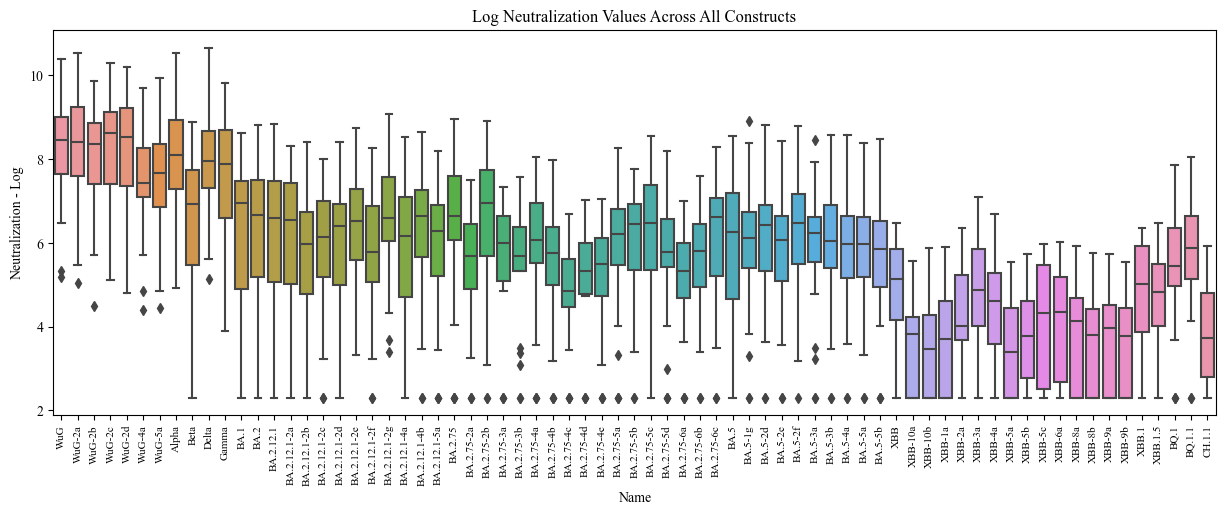

In [187]:
fig, ax = plt.subplots(figsize=(15,5))

sns.boxplot(x='Name',
            y='Neutralization - Log',
            data=data_withSortkey,
            ax=ax)
xtick_labels = ax.get_xticklabels()
ax.set_xticklabels(xtick_labels, rotation=90, fontsize=8);
ax.set_title('Log Neutralization Values Across All Constructs');

fig.savefig('figs/Data_QA/Log_Neutralization_Across_Constructs.png', dpi=200)

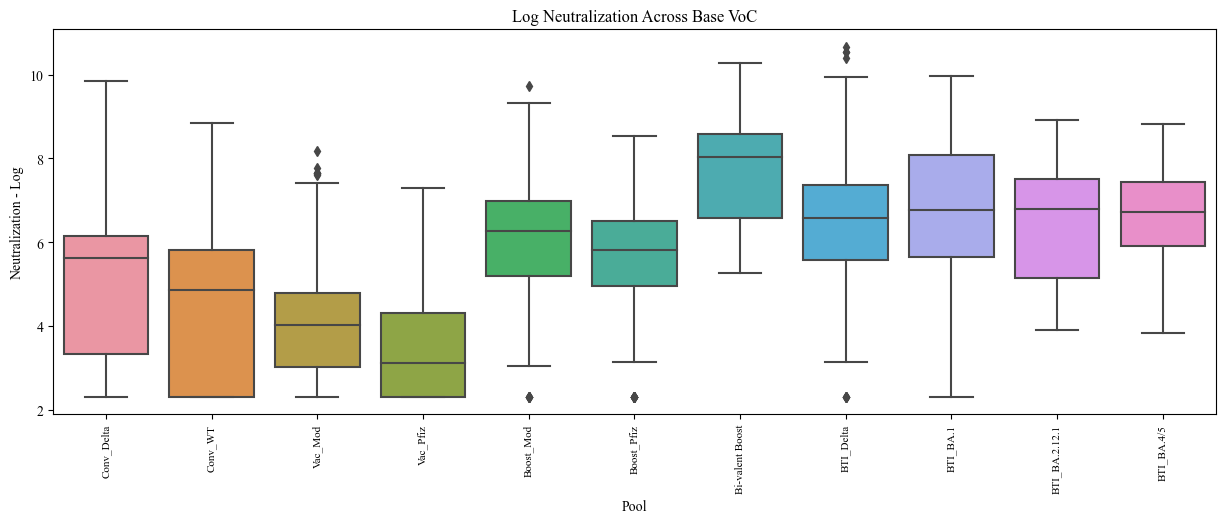

In [188]:
fig, ax = plt.subplots(1,1, figsize=(15,5))
sns.boxplot(x='Pool',
            y='Neutralization - Log',
            data=data_withSortkey,
            ax=ax)
xtick_labels = ax.get_xticklabels()
ax.set_xticklabels(xtick_labels, rotation=90, fontsize=8);
ax.set_title('Log Neutralization Across Base VoC');
fig.savefig('figs/Data_QA/Log_Neutralization_Across_Pools.png', dpi=150)

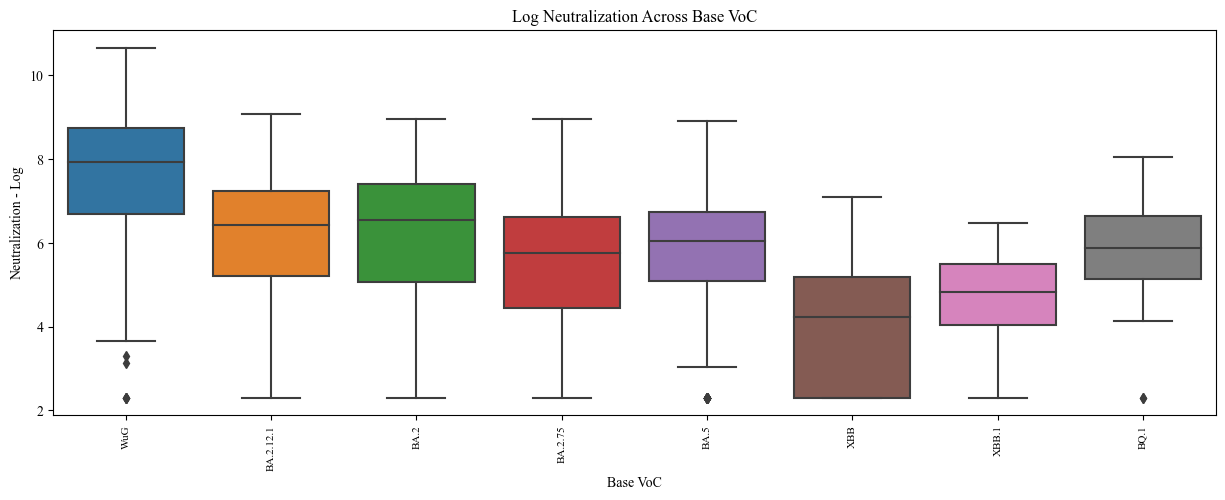

In [189]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot(x='Base VoC',
            y='Neutralization - Log',
            data=data_withSortkey,
            ax=ax)
xtick_labels = ax.get_xticklabels()
ax.set_xticklabels(xtick_labels, rotation=90, fontsize=8);
ax.set_title('Log Neutralization Across Base VoC');
fig.savefig('figs/Data_QA/Log_Neutralization_Across_BaseVoC.png', dpi=150);

C:\Users\blk18\AppData\Local\Temp\ipykernel_2956\1673584518.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xtick_labels, rotation=90, fontsize=8);


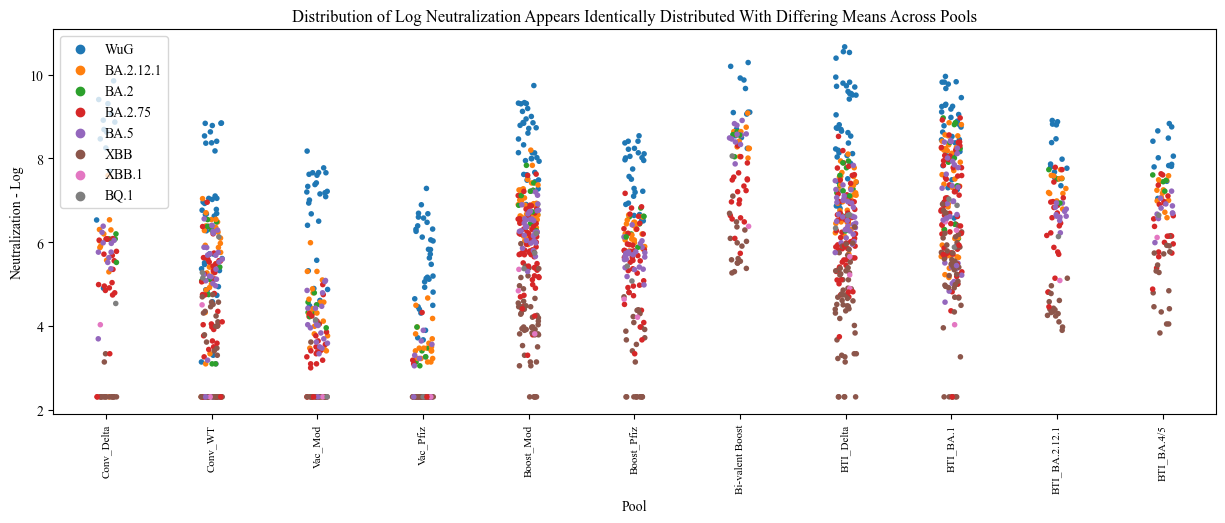

In [190]:
fig, ax = plt.subplots(1,1, figsize=(15,5))
sns.stripplot(jitter=True,
            x='Pool',
            y='Neutralization - Log',
            hue='Base VoC',
            s=4,
            alpha=1,
            data=data_withSortkey,
            ax=ax)
ax.legend(loc='upper left');
xtick_labels = ax.get_xticklabels()
ax.set_xticklabels(xtick_labels, rotation=90, fontsize=8);
ax.set_title('Distribution of Log Neutralization Appears Identically Distributed With Differing Means Across Pools');
fig.savefig('figs/Data_QA/Neutralization_Distribution_Identical_Across_Pools', dpi=150);

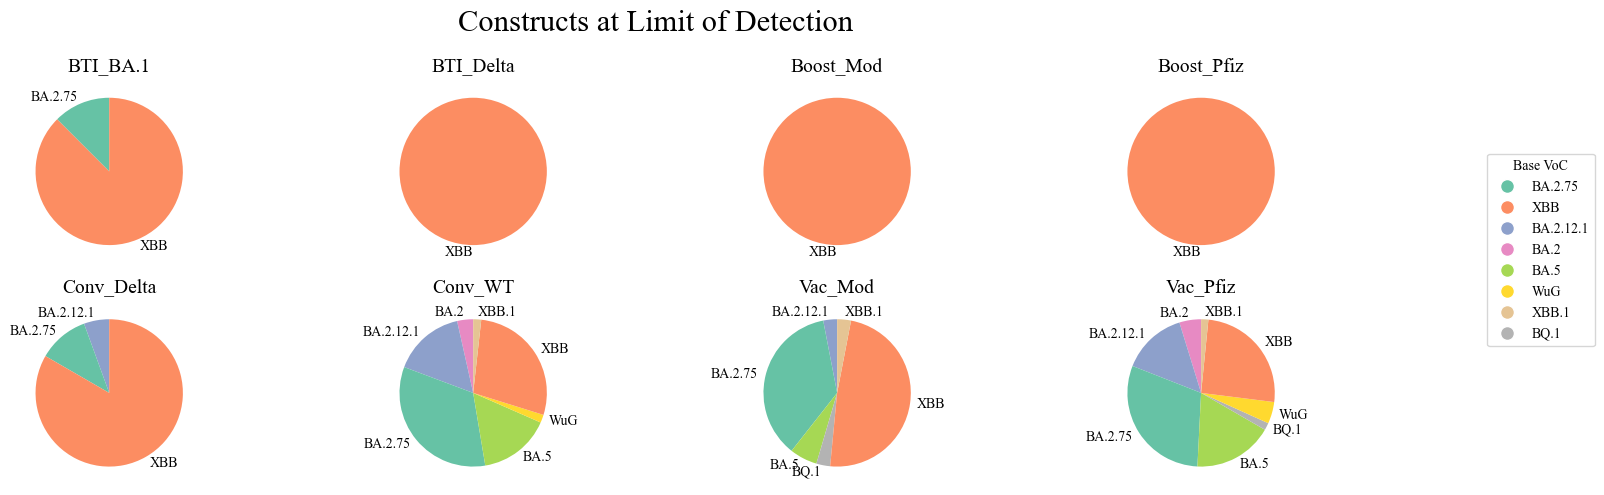

In [191]:
# Filter and group by 'Pool' and 'Base VoC' columns, count occurrences
grouped_df = df[df['Neutralization - Log'] < 2.8].groupby(['Pool', 'Base VoC']).size().reset_index(name='count')

# Create a custom color palette
colors = sns.color_palette("Set2", len(grouped_df['Base VoC'].unique()))

# Create a color mapping dictionary
color_mapping = dict(zip(grouped_df['Base VoC'].unique(), colors))

# Create a pie chart for each group
groups = grouped_df['Pool'].unique()

fig, axes = plt.subplots(2, len(groups)//2, figsize=(15, 5))
for ax, group in zip(axes.flatten(), groups):
    group_data = grouped_df[grouped_df['Pool'] == group]
    
    # Plot a pie chart for the current group with the custom color palette
    ax.pie(group_data['count'], labels=group_data['Base VoC'], startangle=90, colors=[color_mapping[color] for color in group_data['Base VoC']])
    ax.set_title(f'{group}', fontsize=14)

# Create a custom legend using Line2D objects
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_mapping[label], markersize=10, label=label)
                   for label in grouped_df['Base VoC'].unique()]

# Place the legend outside of the pie charts
fig.legend(handles=legend_elements, title='Base VoC', bbox_to_anchor=(1.05, 0.5), loc='center left')
fig.suptitle('Constructs at Limit of Detection', fontsize=22)
fig.tight_layout()
fig.savefig('figs/Data_QA/Neutralization_LOD_VoCs.png', dpi=150)

---
## Model

In [12]:
def one_hot(mutations: pd.Series):
    features = list(set(','.join(filter(None, mutations.tolist())).split(',')))
    onehot = [[1 if mut.strip() in str(muts) else 0 for mut in features] for muts in mutations]
    
    return torch.tensor(onehot, dtype=d), features

In [13]:
# Neutralization Model
def model(X,Y, pools):
    # model: Y = mX + b <--- b is different for each pool
            
    # Sample b for each pool
    μ_b = 5. 
    σ_b = 1.
    with pyro.plate("bpools", len(set(pools))):
        b = pyro.sample("b", dist.Normal(μ_b, σ_b))
        
    # Sample coefficients for each mutation
    μ_m = 0.
    σ_m = pyro.sample('σ_m', dist.Uniform(1e-7, 2))
    with pyro.plate("mutations", X.shape[1]):
        m0 = pyro.sample("m0", dist.Normal(μ_m, σ_m)).unsqueeze(1)
    # # Sample coefficients for each pool
    with pyro.plate("mpools", len(set(pools))):
        mp = pyro.sample("mp", dist.Normal(m0, σ_m))
        
    # Make predictions
    pred_neutralization = torch.matmul(X,mp)[torch.arange(X.shape[0]),pools] + b[pools]
    
    # Score observation
    σ = pyro.sample("σ", dist.Uniform(1e-7, 2))
    with pyro.plate("data", X.shape[0]):
        return pyro.sample("obs", dist.Normal(pred_neutralization, σ), obs=Y)

In [25]:
X, features = one_hot(df['All mutations'])
Y = torch.tensor(df['Neutralization - Log'].values, dtype=d)
pools = df['Pool ID'].tolist()

mcmc_data = dict()
mcmc_data['X'] = X
mcmc_data['Y'] = Y
mcmc_data['features'] = features
mcmc_data['pools'] = pools

---
## MCMC

In [28]:
def save_mcmc(posterior_samples, mcmc_data):
    # MCMC output:
    folder = 'model_neutralization/' + dt.strftime(dt.now(), '%Y-%m-%d') + '/'
    chain_file = 'mcmc_chain.pkl'
    data_file = 'mcmc_input_data.pt'

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    # Save chain
    with open(folder+chain_file, 'wb') as f:
        pickle.dump(posterior_samples, f)
    
    # Save input data for model
    torch.save(mcmc_data, folder+data_file)
    
def load_mcmc(folder):
    # MCMC output:
    chain_file = 'mcmc_chain.pkl'
    data_file = 'mcmc_input_data.pt'
        
    # Load chain
    with open(folder+chain_file, 'rb') as f:
        posterior_samples = pickle.load(f)
    
    # Load input data for model
    mcmc_data = torch.load(folder+data_file)
    
    return posterior_samples, mcmc_data

In [34]:
if run_MCMC:
    pyro.clear_param_store()
    
    nuts_kernel = NUTS(model)

    mcmc = MCMC(nuts_kernel, num_samples=1500, warmup_steps=1500)
    mcmc.run(X, Y, pools)

    posterior_samples = mcmc.get_samples()
    
    # Save 
    save_mcmc(posterior_samples, mcmc_data)
    
else:
    folder = 'model_neutralization/2023-12-11/'
    posterior_samples, mcmc_data = load_mcmc(folder)
    assert X == mcmc_data['X']
    assert Y == mcmc_data['Y']
    assert features == mcmc_data['features']
    assert pools == mcmc_data['pools']

#### Inspect Traces for Convergence

5it [00:00,  9.40it/s]


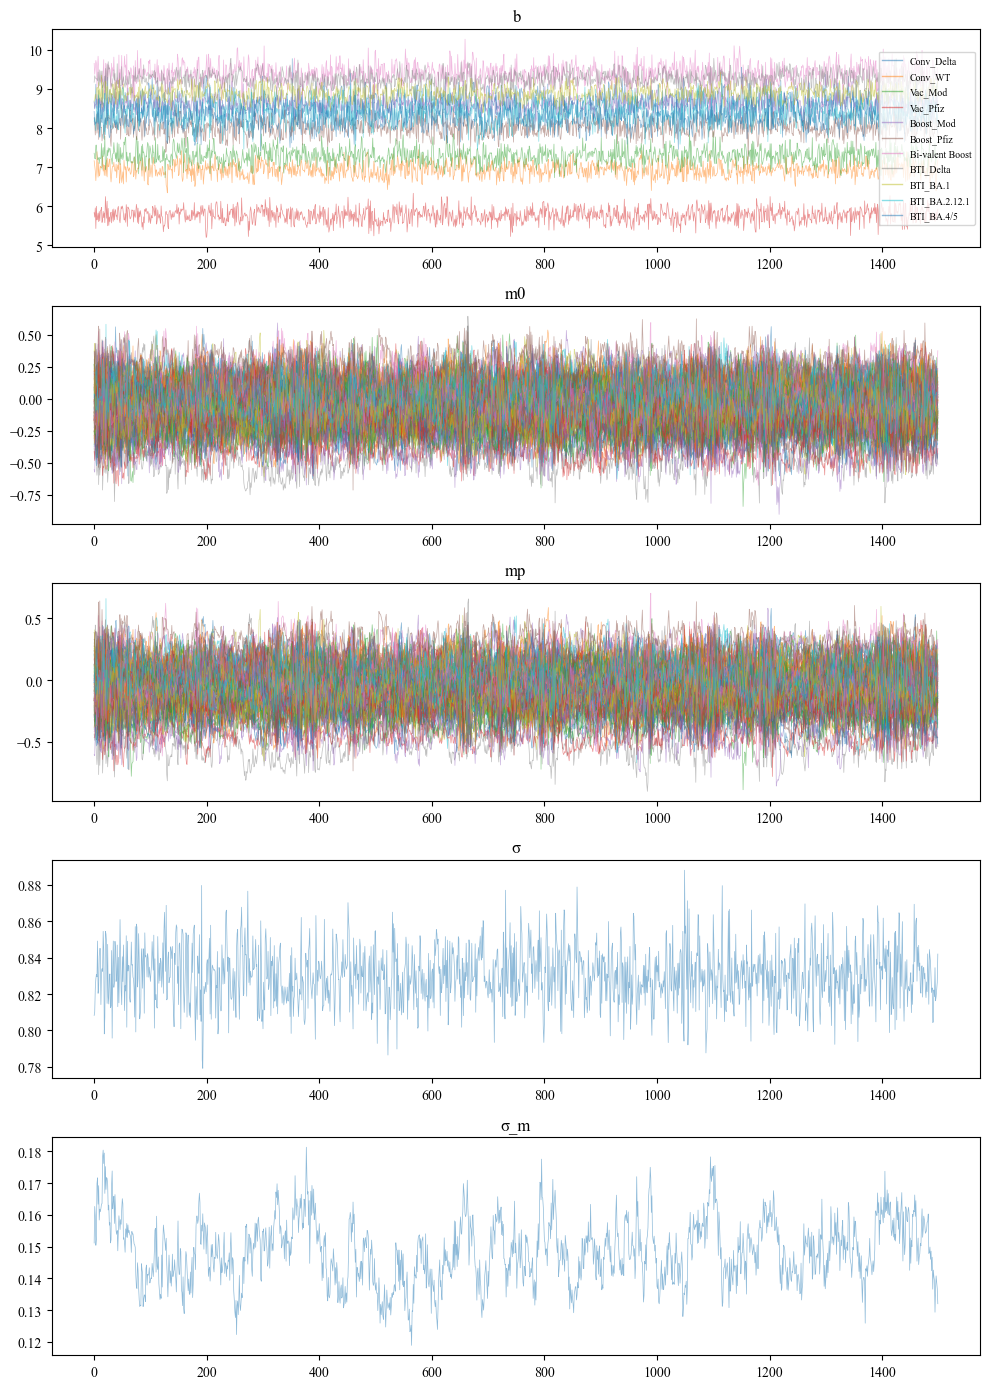

In [37]:
# Show all traces at once
def plot_trace(samples):
    num_trace = len(samples.keys())
    
    fig, axes = plt.subplots(num_trace, 1, figsize=(10, 14))
    axes = axes.flatten()
    
    def get_labels(k):
        if k=='b':
            return df['Pool'].unique()
        elif k.startswith('m'):
            return features
        return k
        
    for key, ax in tqdm(zip(samples.keys(),axes)):
        trace = samples[key]
        # If there are more than two dimensions, keep flattening via avg until there are only 2 dimensions
        while len(trace.shape)>2:
            trace = trace.mean(dim=-1)
            
        ax.plot(trace.detach().numpy(), label=get_labels(key), linewidth=0.5, alpha=0.5)
        ax.set_title(key)
        if key=='b':
            leg = ax.legend(ncol=1, fontsize=7, loc='right')
            # set the linewidth of each legend object
            for legobj in leg.legendHandles:
                legobj.set_linewidth(1.0)
        
        fig.tight_layout()
        
    return fig, axes
        
fig, axes = plot_trace(posterior_samples)
fig.savefig('figs/Model_Diagnostics/neutralization_traces.png', dpi=150)

---
## Evaluate Model Fit

In [38]:
def pred_y(X, mp, b, pools):
    return torch.matmul(X,mp)[torch.arange(X.shape[0]),pools] + b[pools]

Y_pred = pred_y(X,
                posterior_samples['mp'].mean(dim=0),
                posterior_samples['b'].mean(dim=0),
                df['Pool ID'].tolist()
               )

In [39]:
print('SSE: {:.2f}'.format(sum((Y_pred - Y)**2)))
print('Avg abs Error Per Obs: {:.4f}'.format(sum((Y_pred - Y)**2).sqrt() / len(Y)))

SSE: 1037.99
Avg abs Error Per Obs: 0.0195


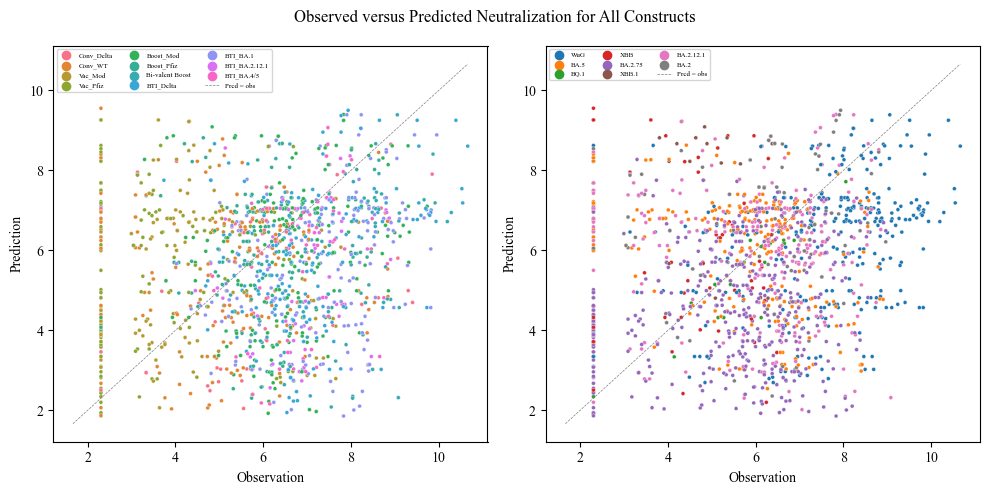

In [42]:
# QQ Plot
def qqplot(ax, hue):
    sns.scatterplot(x='Observation',
                y='Prediction',
                hue=hue,
                s=8,
                alpha=1,
                data=pd.concat([df, pd.Series(Y_pred)], axis=1).rename(columns={'Neutralization - Log':'Observation', 0:'Prediction'}),
                ax=ax
               )
    mi, ma = min(torch.cat([Y, Y_pred])), max(torch.cat([Y, Y_pred])) 
    ax.plot([mi, ma], [mi, ma], linestyle='--', linewidth=0.5, color='gray', label='Pred = obs')
    ax.legend(ncol=3, fontsize=5)
    ax.set_xlabel('Observation');
    ax.set_ylabel('Prediction');
    
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
qqplot(axes[0], 'Pool')
qqplot(axes[1], 'Base VoC')
fig.suptitle('Observed versus Predicted Neutralization for All Constructs')
fig.tight_layout()
fig.savefig('figs/Model_Diagnostics/predictions_vs_observations.png', dpi=150)

---
## Save CSVs of Results

In [162]:
def mutation_effects_within_pools(samples, pool_names, features):
    column_names = pool_names
    row_names = features
    mutations_within_pools = pd.DataFrame(data=samples['mp'].mean(dim=0),
                                  index=row_names, 
                                  columns=column_names)
    mutations_within_pools = pd.melt(mutations_within_pools.reset_index(), var_name='Pool', value_name='Mean Effect', id_vars='index').rename(columns={'index':'Mutation'})
    
    return mutations_within_pools

def count_mutations_within_pools(X, features, pool_to_id):
    mut_counts = pd.DataFrame(X.detach().numpy(), columns=features)
    mut_counts['Pool ID'] = pools
    mut_counts = pd.melt(mut_counts, id_vars=['Pool ID'], var_name='Mutation', value_name='N')
    mut_counts = mut_counts.groupby(['Pool ID', 'Mutation']).agg('sum').reset_index()
    mut_counts = pd.merge(mut_counts, pool_to_id, on='Pool ID').drop(columns='Pool ID')
    return mut_counts

def mutation_effects_across_pools(samples):
    mutations_across_pools = pd.DataFrame(data=samples['m0'].mean(dim=0),
                                          index=features
                                         ).reset_index(
                                         ).rename(columns={'index':'Mutation', 0:'Mean Effect'})
    return mutations_across_pools

def count_mutations(X, features):
    mut_counts = pd.DataFrame(data=X.sum(dim=0),
                              index=features
                             ).reset_index(
                             ).rename(columns={'index':'Mutation', 0:'N'})
    return mut_counts

def get_baselines(samples, pools, pool_to_id):
    baselines = pd.DataFrame(data=samples['b'].mean(dim=0),
                             index=sorted(set(pools))
                           ).reset_index(
                           ).rename(columns={'index':'Pool ID', 0:'Mean Effect'})
    counts = pd.DataFrame(data=pools)
    counts['Count'] = 1
    counts = counts.groupby(0).agg('count').reset_index().rename(columns={0:'Pool ID', 'Count':'N'})
    baselines = pd.merge(baselines, counts, on='Pool ID')
    baselines = pd.merge(baselines, pool_to_id, on='Pool ID').drop(columns='Pool ID')
    
    return baselines

In [182]:
outfolder = 'results/' + dt.strftime(dt.now(), '%Y-%m-%d') + '/'
if not os.path.exists(outfolder):
    os.makedirs(outfolder)

# Mutation effects within pools
outfile = 'mutation_effects_within_pools.csv'
pool_names = list(set(df['Pool']))
pool_to_id = df[['Pool ID', 'Pool']].drop_duplicates()
mutations_within_pools =  mutation_effects_within_pools(posterior_samples, pool_names, features)
counts = count_mutations_within_pools(X, features, pool_to_id)
mutations_within_pools = pd.merge(mutations_within_pools, counts, on=['Pool', 'Mutation']).sort_values(by='Mean Effect')
mutations_within_pools.to_csv(outfolder + outfile, index=False)

# Mutation effects across pools
outfile = 'mutation_effects_across_pools.csv'
mutations_across_pools =  mutation_effects_across_pools(posterior_samples)
counts = count_mutations(X, features)
mutations_across_pools = pd.merge(mutations_across_pools, counts, on='Mutation').sort_values(by='Mean Effect')
mutations_across_pools.to_csv(outfolder + outfile, index=False)

# Pool baselines
outfile = 'baseline_effects.csv'
baselines = get_baselines(posterior_samples, pools, pool_to_id)
baselines.to_csv(outfolder + outfile, index=False)

# Predictions vs Observations
outfile = 'predictions_vs_observations.csv'
pred_vs_obs = df[['Name', 'Base VoC', 'Pool', 'Neutralization - Log']].copy()
pred_vs_obs['Predicted Neutralization - Log'] = Y_pred
pred_vs_obs.to_csv(outfolder + outfile, index=False)

---
## Explore Model Results

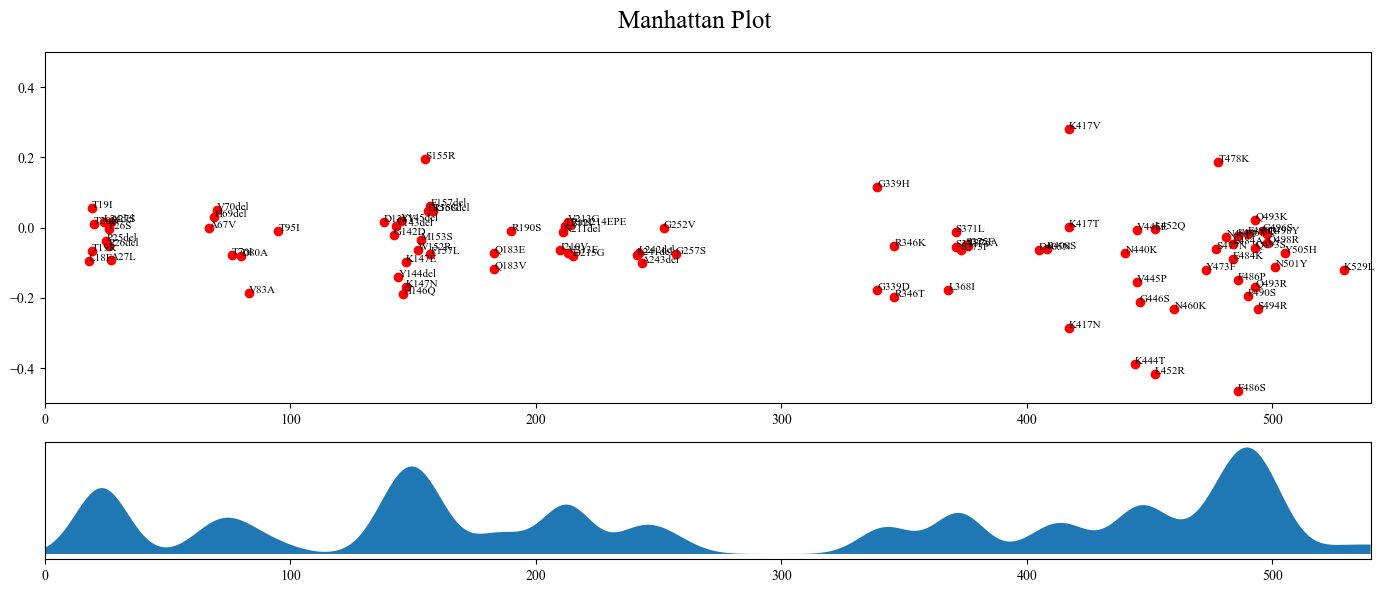

In [43]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 540]
    options['ylim'] = [-0.5, 0.5]#[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

def preprocess_manhattan(samples, labels):
    means = samples.mean(dim=0)
    coefficients = labels.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return means, positions, coefficients

def plot_coef(ax, means, positions, coefficients, optoins):
    ax.plot(positions, means, 'ro')
    
    texts = []
    for i, (pos, fea) in enumerate(zip(positions, coefficients)):
        x = pos
        y = means[i]
        text = fea #+ '\n' + '{:1.2f}'.format(y)
        texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    ylim = options['ylim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde


fig, axes, options = setup()
all_means, positions, coefficients = preprocess_manhattan(posterior_samples['m0'], features)
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], all_means, positions, coefficients, options)
fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()
fig.savefig('figs/Results/Neutralization_Manhattan.png', dpi=150)

121it [00:01, 88.34it/s]
100%|████████████████████████████████████████████████████████████████████████████████| 121/121 [00:02<00:00, 52.91it/s]


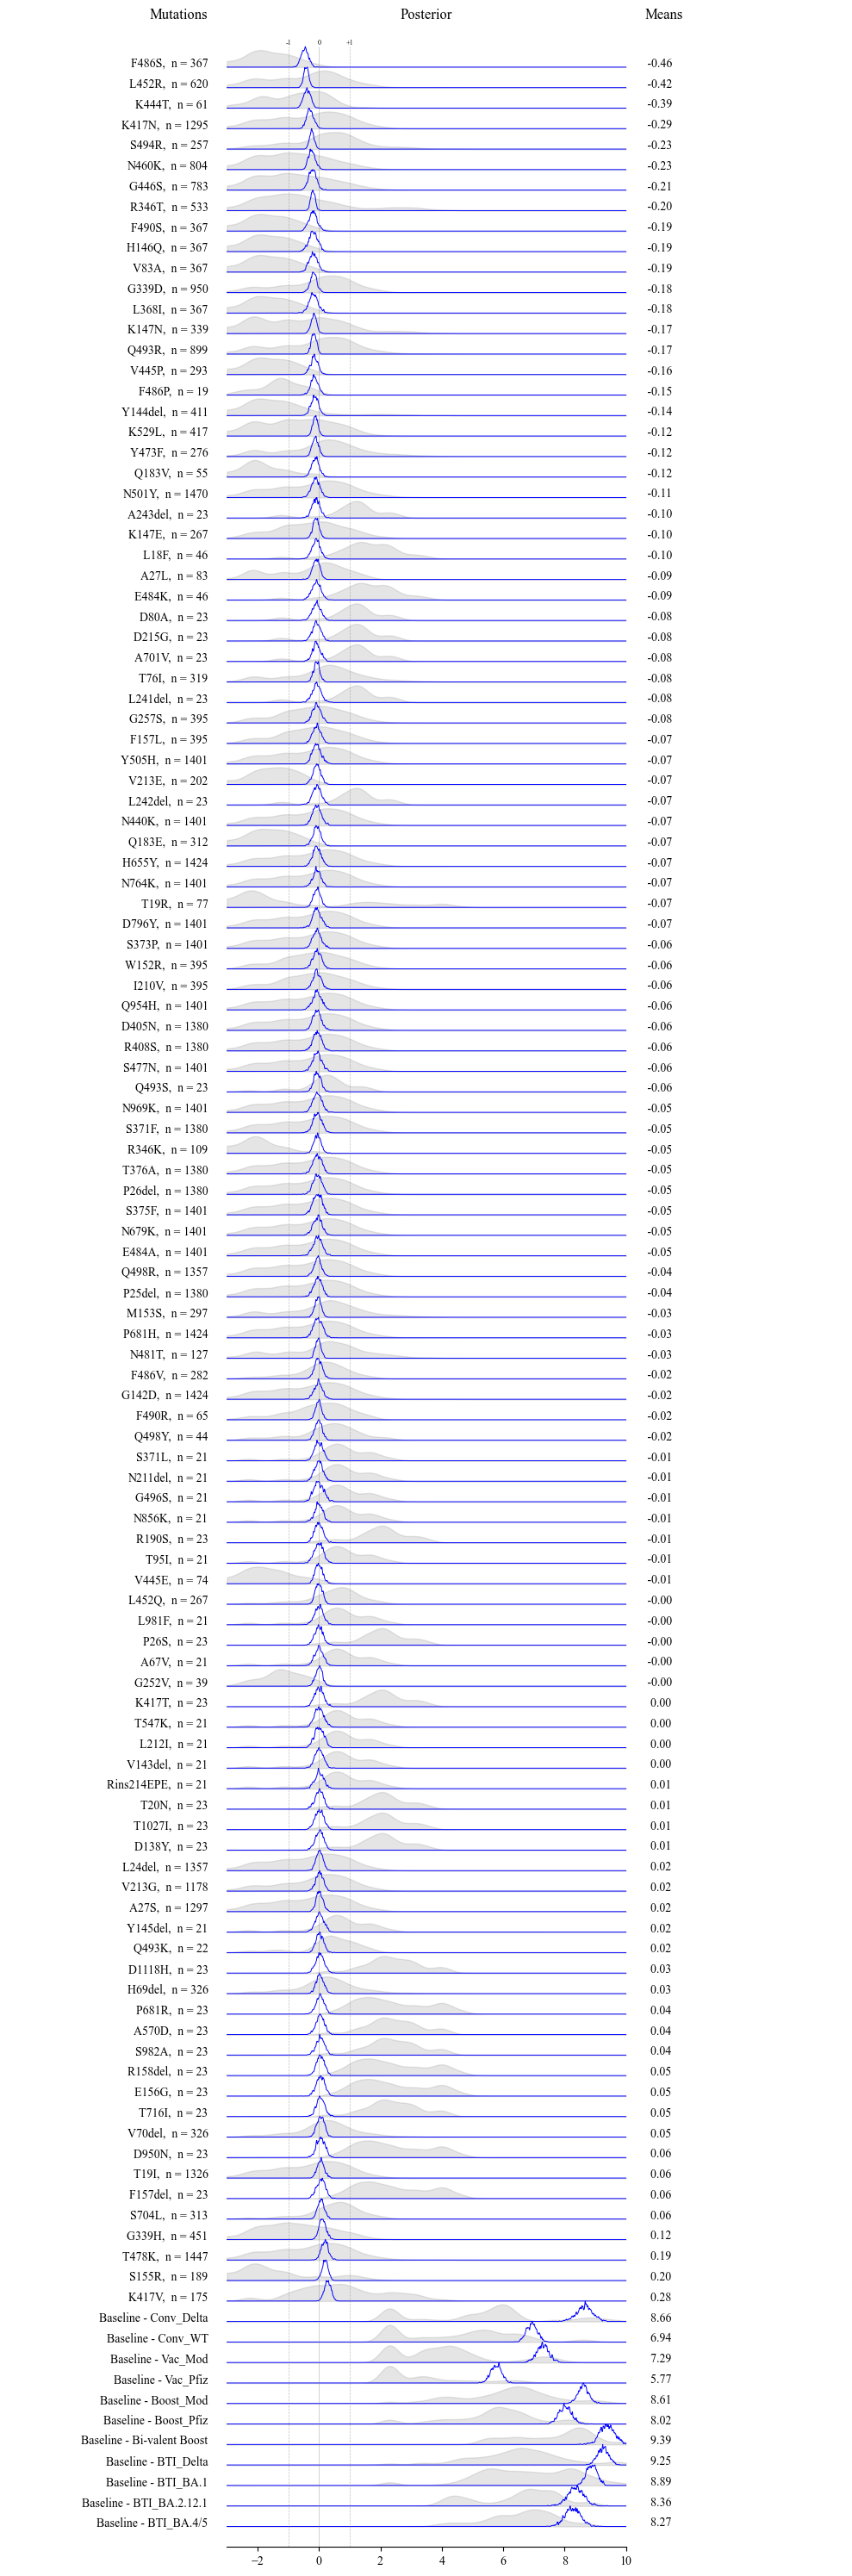

In [52]:
def preprocess_kde(samples, labels, pools):
    m_samples = samples['m0']
    b_samples = samples['b']
    all_samples = torch.cat((m_samples, b_samples), dim=1)  # put β at the end
    coefficients = labels.copy()
    sort_by = all_samples.mean(dim=0)
    sort_by = sort_by[:-1]  # intercept is the last term in this tensor
    coef_map = {x:i for i, (_,x) in enumerate(sorted(zip(sort_by, labels)))}#, reverse=True))}
    # Add intercept term last
    for i, p in enumerate(pools):
        coefficients.append(f'Baseline - {p}')
        coef_map[f'Baseline - {p}'] = len(coefficients)-1
    return all_samples, coefficients, coef_map

def setup(fig, axes, samples):
    options = {}
    options['scale'] = 1
    options['xlim'] = [-3, 10]
    options['ymax'] = samples.shape[1]
    
    axes[1].spines.right.set_visible(False)
    axes[1].spines.left.set_visible(False)
    axes[1].spines.top.set_visible(False)
    axes[1].set_yticks([])
    axes[1].set_yticklabels([])
    
    axes[0].axis('off')
    axes[2].axis('off')
    
    plt.rcParams['font.family'] = ['Times New Roman']
    return options

def plot_kdes(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    xlim = options['xlim']
    num_points = 1000
    color='blue'
    
    linecolor = 'blue'
    linewidth = 0.7
    
    for i, coef in tqdm(enumerate(coefficients)):
        base_y = (ymax - coef_map[coef])  # coef_map[coef]  
        sample_idx = i
        # Fit KDE
        s = samples[:, sample_idx]
        kde = KDE(kernel='gaussian', bandwidth=0.01).fit(s.reshape(-1,1))
        x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
        # Generate KDE curve
        y = np.exp(kde.score_samples(x))
        # Scale curve
        y /= (scale*max(y))
        # Move y up to the desired height
        y += base_y
        
        
        ax.plot(x, y, 
                color=color, linewidth=linewidth)
        
    ax.set_xlim(xlim)
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Posterior', loc='center')
    
def annotate_means(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    means = {}
    coefs = list(coef_map.keys())
    for i, c in enumerate(coefficients):
        mean = samples[:,i].mean()
        means[c] = mean.item()
        t = '{:6.2f}'.format(mean)
        y = ymax - coef_map[c]
        ax.text(0, y, t,
                ha='left')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Means', loc='left')
    
    return means
    
def affordances(ax, options):
    ax.vlines(0, 0, options['ymax']+options['scale'],
             color='gray', linewidth=0.5, alpha=0.5)
    ax.vlines(1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.vlines(-1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.text(0, options['ymax']+options['scale'], '0', ha='center', va='bottom', fontsize=6)
    ax.text(1, options['ymax']+options['scale'], '+1', ha='center', va='bottom', fontsize=6)
    ax.text(-1, options['ymax']+options['scale'], '-1', ha='center', va='bottom', fontsize=6)

def annotate_posterior_with_n(ax, coefficients, coef_map, X, features, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    pos = [ymax - i for i in range(ymax)]
    labels = list(coef_map.keys())
    for y, t in zip(pos, labels):
        if t in features:
            i = features.index(t)
            n=X.sum(dim=0)[i]
            t = t + f',  n = {int(n)}'
            
            # f'n={int(n)}'.ljust(10)
        
        ax.text(1, y, t,
                ha='right')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Mutations', loc='right')

def get_obs(df, means):
    avgs = pd.DataFrame()
    for c, i in means.items():
        if c.startswith('Baseline'):
            pool = c.split(' - ')[1]
            avgs = pd.concat([avgs, 
                              pd.DataFrame([{'Pool':pool, 'Mean MCMC':means[c]}])])
    
    df2 = df[['Pool', 'Neutralization - Log']
            ].groupby('Pool'
            ).agg('mean'
            ).reset_index(
            ).rename(columns={'Neutralization - Log':'Mean Obs'})
    df2 = pd.merge(df2, avgs, on='Pool')
    
    df2 = pd.merge(df, df2, on='Pool')
    df2['Pool Relative Neutralization'] = df2['Neutralization - Log'] - df2['Mean Obs']
    
    return df2

def kde_obs(ax, obs, coef_map, options):
    scale = options['scale']+0.2
    ymax = options['ymax']
    xlim = options['xlim']
    num_points = 1000
    color='blue'
    
    linecolor = 'gray'
    linewidth = 0.7

    for coef in tqdm(coefficients):
        base_y = (ymax - coef_map[coef])  # coef_map[coef]  
        
        if coef.startswith('Baseline'):
            pool = coef.split(' - ')[1]
            s = obs[obs['Pool']==pool]['Neutralization - Log']
        else:
            s = obs[obs['All mutations'].apply(lambda x: coef in x if isinstance(x, str) else False)]['Pool Relative Neutralization']
        
        s = np.array(s)
        kde = KDE(kernel='gaussian', bandwidth=0.3).fit(s.reshape(-1,1))
        x = np.linspace(xlim[0], xlim[1], num_points)
        # Generate KDE curve
        y = np.exp(kde.score_samples(x.reshape(-1,1)))
        # Scale curve
        y /= (scale*max(y))
        # Move y up to the desired height
        y += base_y
        
        
        # ax.plot(x, y, 
        #         color=color, linewidth=linewidth, alpha=0.5)
        ax.fill_between(x,
                        base_y, 
                        y, 
                        color='gray', alpha=0.2);
        
        
all_samples, coefficients, coefficient_map = preprocess_kde(posterior_samples, features, df['Pool'].unique())

fig, axes = plt.subplots(1, 3, figsize=(10, 30), gridspec_kw={'width_ratios': [1, 2, 1]})

options = setup(fig, axes, all_samples)
plot_kdes(axes[1], all_samples, coefficients, coefficient_map, options)
annotate_posterior_with_n(axes[0], coefficients, coefficient_map, X, features, options)
means = annotate_means(axes[2], all_samples, coefficients, coefficient_map, options)
affordances(axes[1], options)

obs = get_obs(df, means)
kde_obs(axes[1], obs, coefficient_map, options)

fig.tight_layout()
fig.savefig('figs/Results/neutralization_posterior_with_observations.png', dpi=150)

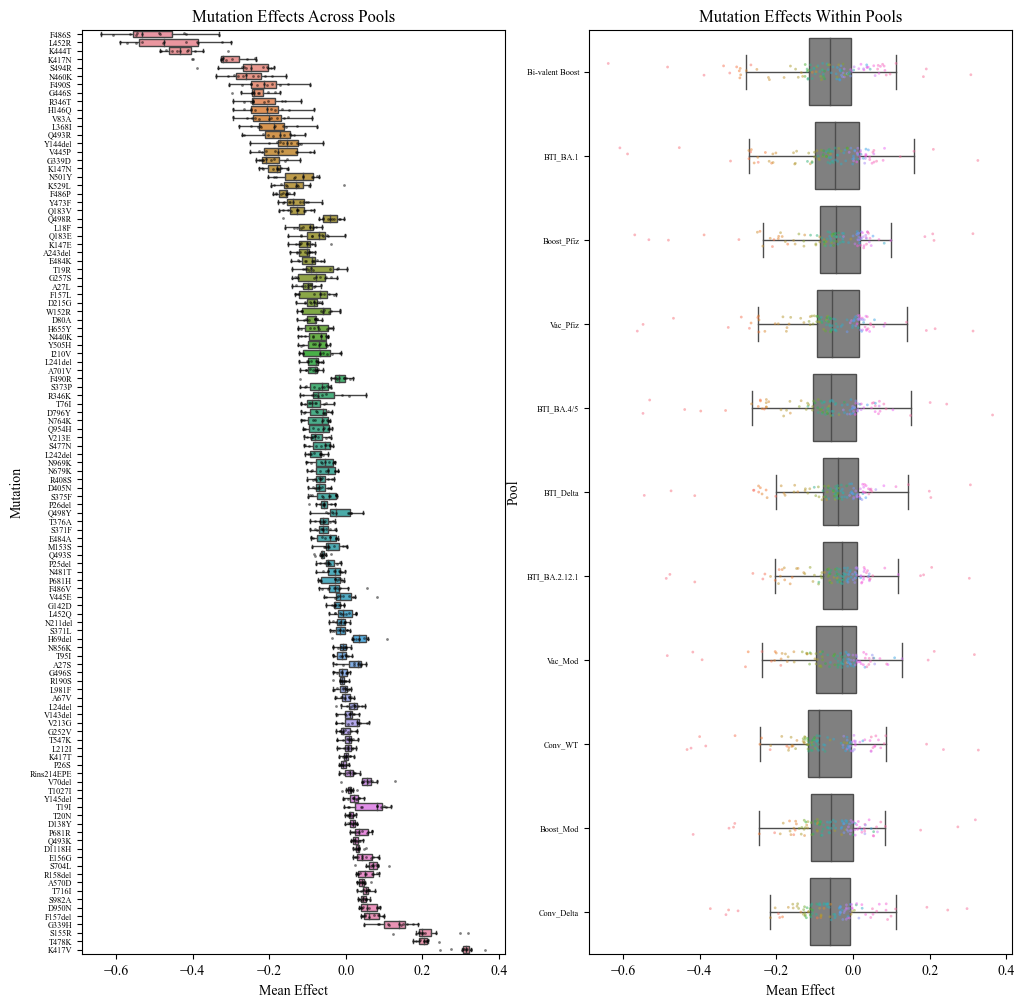

In [183]:
fig, axes = plt.subplots(1,2,figsize=(12,12))

ax = axes[0]
sns.boxplot(x='Mean Effect',
            y='Mutation',
            data=mutations_within_pools.sort_values(by='Mean Effect'),
            linewidth=1,
            showfliers=False,
            ax=ax)

sns.stripplot(x='Mean Effect',
            y='Mutation',
            data=mutations_within_pools.sort_values(by='Mean Effect'),
            jitter=True,
            color='k',
            size=2,
            alpha=0.5,
            ax=ax)

ax.tick_params(axis='y', labelsize=6)
ax.set_title('Mutation Effects Across Pools');

ax = axes[1]
sns.boxplot(x='Mean Effect',
            y='Pool',
            color='gray',
            data=mutations_within_pools.sort_values(by='Mean Effect'),
            linewidth=1,
            showfliers=False,
            ax=ax)

sns.stripplot(x='Mean Effect',
            y='Pool',
            hue='Mutation',
            data=mutations_within_pools.sort_values(by='Mean Effect'),
            jitter=True,
            # color='k',
            size=2,
            alpha=0.5,
            ax=ax)

ax.legend().set_visible(False)
ax.tick_params(axis='y', labelsize=6)
ax.set_title('Mutation Effects Within Pools');
fig.savefig('figs/Results/mutation_effect_ranges.png', dpi=150)

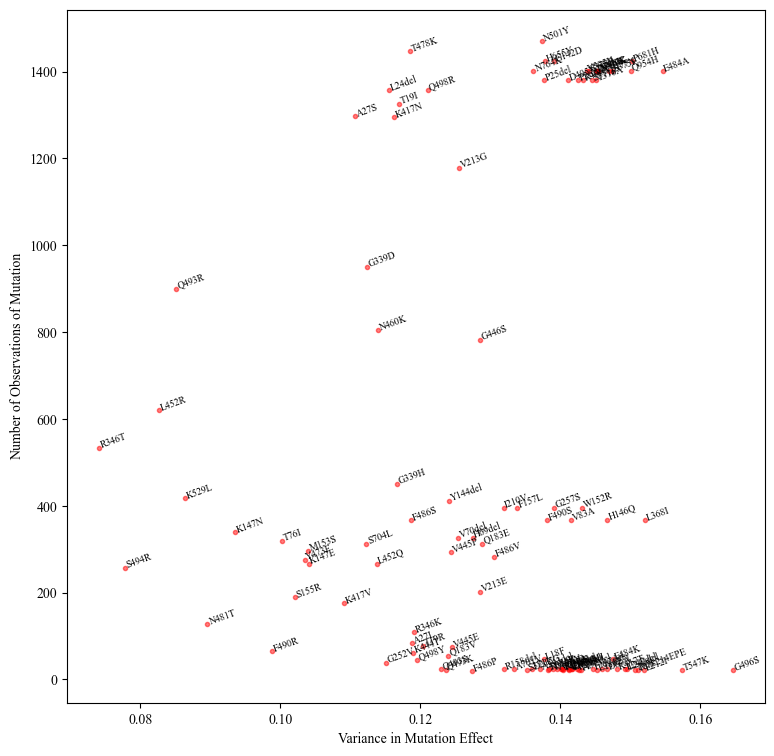

In [186]:
# Volcano Plots
fig, ax = plt.subplots(figsize=(9,9))
n = X.sum(dim=0)
ax.plot(posterior_samples['m0'].std(dim=0), n,
        marker='o', color='red', markersize=3, alpha=0.5,
        linestyle='');

for i, f in enumerate(features):
    # if n[i] > 750 or posterior_samples['m'].std(dim=0)[i] < 0.5:
    ax.text(posterior_samples['m0'].std(dim=0)[i],
            n[i],
            f,
            fontsize=7,
            rotation=20)

ax.set_xlabel('Variance in Mutation Effect');
ax.set_ylabel('Number of Observations of Mutation');

fig.savefig('figs/Results/not-volcano.png', dpi=150)